In [ ]:
# Imports y configuraciones basicas
import os
import ast
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns

# ==========================================
# CONFIGURACIONES Y CONSTANTES GLOBALES
# ==========================================
sns.set_style("whitegrid") 

PERIODOS = [
    ('Primera Ola', '2020-06-01', '2020-10-31'),
    ('Intermedia', '2020-11-01', '2021-02-28'),
    ('Segunda Ola', '2021-03-01', '2021-07-31'),
    ('Post-vacunación', '2021-08-01', '2022-12-31')
]

MAPA_FORMAS = {'dot': 'o', 'star': '*'}
MAPA_ESTADOS = {'criticas': 3, 'intermedias': 2, 'generales': 1}
COLORES_ORIGEN = {'Desde MÓDULO': '#d73027', 'Desde UPA': '#fdae61', 'Desde HOSPITAL': '#1a9850'}

# ==========================================
# FUNCIONES AUXILIARES (DRY)
# ==========================================
def clasificar_hospital(nombre):
    n = str(nombre).upper()
    if 'MODULO' in n or 'MÓDULO' in n: return 'Desde MÓDULO'
    elif 'UPA' in n: return 'Desde UPA'
    return 'Desde HOSPITAL'

def asignar_color_origen(nombre):
    return COLORES_ORIGEN[clasificar_hospital(nombre)]

def redondear_estetico(valor):
    if valor <= 10: return 10
    if valor <= 100: return int(np.ceil(valor / 10) * 10)
    if valor <= 500: return int(np.ceil(valor / 50) * 50)
    return int(np.ceil(valor / 100) * 100)

def guardar_grafico_alta_calidad(nombre_archivo, bbox="tight"):
    ruta_salida = "results/outputs/red"
    os.makedirs(ruta_salida, exist_ok=True)
    ruta_completa = f"{ruta_salida}/{nombre_archivo}"
    
    plt.savefig(f"{ruta_completa}.png", dpi=300, bbox_inches=bbox, facecolor="white")
    plt.savefig(f"{ruta_completa}.svg", format="svg", bbox_inches=bbox)
    plt.savefig(f"{ruta_completa}.pdf", format="pdf", bbox_inches=bbox)
    print(f"Gráficos exportados en: {ruta_salida}")

In [ ]:
# CARGA Y LIMPIEZA DE DATOS
# ==========================================
pacientes = pd.read_excel("C:/Users/micag/Documents/RedesHospitales/data/pacientes.xlsx")
hospitales = pd.read_csv("C:/Users/micag/Documents/RedesHospitales/data/hospitales_coordenadas.csv")

# Diccionarios de referencia
dict_complejidad = dict(zip(hospitales['Nombre Hospital'], hospitales['complejidad']))
hospitales['color_rgb'] = hospitales['color'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
hospitales['forma_nodo'] = hospitales['shape'].map(MAPA_FORMAS)

pacientes = pacientes.rename(columns={
    'Id Hospital': 'hospital_id', 'Nombre Hospital': 'hospital_origen', 'Id': 'paciente_id',
    'Fecha inicio': 'fecha_ingreso', 'Estado al ingreso': 'estado_ingreso', 'Tipo al ingreso': 'tipo_ingreso',
    'Fecha egreso': 'fecha_egreso', 'Motivo': 'motivo_egreso'
})

pacientes['hospital_origen'] = pacientes['hospital_origen'].replace({
    'Módulo Hospitalario 11- FV': 'Módulo Hospitalario 11 - FV',
    'Módulo Hospitalario  9 - AB': 'Módulo Hospitalario 9 - AB'
})

pacientes['fecha_ingreso'] = pd.to_datetime(pacientes['fecha_ingreso'], errors='coerce')
pacientes['fecha_egreso'] = pd.to_datetime(pacientes['fecha_egreso'], errors='coerce')
pacientes = pacientes.sort_values(['paciente_id', 'fecha_ingreso']).reset_index(drop=True)

# CORE DEL MODELO: Traslados
pacientes['hospital_destino'] = pacientes.groupby('paciente_id')['hospital_origen'].shift(-1)
pacientes['fecha_ingreso_destino'] = pacientes.groupby('paciente_id')['fecha_ingreso'].shift(-1)
pacientes['estado_destino'] = pacientes.groupby('paciente_id')['estado_ingreso'].shift(-1)
pacientes['tipo_destino'] = pacientes.groupby('paciente_id')['tipo_ingreso'].shift(-1) 

pacientes['dias_traslado'] = (pacientes['fecha_ingreso_destino'] - pacientes['fecha_egreso']).dt.days
pacientes.loc[pacientes['dias_traslado'] == -1, 'dias_traslado'] = 0

motivos_validos = ['traslado-otro', 'traslado-hospital-de-la-red', 'traslado-extra-sanitario']
mask_traslados = (pacientes['hospital_destino'].notna() & pacientes['motivo_egreso'].isin(motivos_validos) & (pacientes['hospital_origen'] != pacientes['hospital_destino']))

df_potenciales = pacientes[mask_traslados].copy() 
df_traslados = df_potenciales[df_potenciales['dias_traslado'] <= 100].rename(columns={'hospital_origen': 'hospital_ingreso'})
df_traslados['alerta_demora'] = df_traslados['dias_traslado'] > 3
df_traslados['dias_alerta'] = df_traslados.apply(lambda row: row['dias_traslado'] if row['alerta_demora'] else 0, axis=1)

# ==========================================
# PREPARACIÓN DE COORDENADAS (Unificado)
# ==========================================
df_coordenadas = hospitales.rename(columns={'Nombre Hospital': 'hospital', 'Latitud': 'lat', 'Longitud': 'lon'})

# Ajustes manuales unificados (valores finales)
df_coordenadas.loc[df_coordenadas['hospital'] == 'Módulo Hospitalario 8 - LZ', 'lon'] += 0.06
df_coordenadas.loc[df_coordenadas['hospital'] == 'UPA 10 - BE', 'lon'] -= 0.06
df_coordenadas.loc[df_coordenadas['hospital'] == 'Evita Pueblo', 'lon'] -= 0.03

# Desplazar duplicados
nuevas_filas = []
for (lat, lon), group in df_coordenadas.groupby(['lat', 'lon']):
    for i, (_, row) in enumerate(group.iterrows()):
        row_mod = row.copy()
        if i > 0:
            row_mod['lon'] = lon + 0.01   
            row_mod['lat'] = lat + (i * 0.015)  
        nuevas_filas.append(row_mod)

df_coordenadas = pd.DataFrame(nuevas_filas)
hospitales_conocidos = set(df_coordenadas['hospital'])

In [ ]:
# Funciones de visualizacion
###########################################

def aplicar_escala_visual(valor, max_valor, v_min, v_max, tipo='sqrt', min_valor=0):
    if max_valor == min_valor or valor == 0: 
        return v_min if valor > 0 else 0
    
    # Respetamos tu normalización original Min-Max Lineal para la escala cuadrática
    if min_valor > 0 and tipo == 'cuadratica':
        x = (valor - min_valor) / (max_valor - min_valor)
    else:
        x = valor / max_valor
        
    escala = np.sqrt(x) if tipo == 'sqrt' else (x**2 if tipo == 'cuadratica' else x)
    return v_min + (escala * (v_max - v_min))

def dibujar_grafo_nx(ax, G, posiciones, max_traslados, max_ingresos, cfg):
    """ Función genérica para renderizar nodos, aristas y etiquetas """
    # 1. Dibujar Nodos
    for forma in set(nx.get_node_attributes(G, 'shape').values()):
        nodelist = [n for n in G.nodes() if G.nodes[n]['shape'] == forma]
        nodos = nx.draw_networkx_nodes(
            G, posiciones, nodelist=nodelist, ax=ax, node_shape=forma, 
            node_color=[G.nodes[n]['color'] for n in nodelist], 
            node_size=[G.nodes[n]['size'] for n in nodelist], 
            alpha=[G.nodes[n]['alpha'] for n in nodelist], edgecolors='white', linewidths=cfg.get('lw_nodos', 0.5)
        )
        if nodos and 'zorder_nodos' in cfg: nodos.set_zorder(cfg['zorder_nodos'])

    # 2. Dibujar Aristas
    for u, v, data in G.edges(data=True):
        peso = data['weight']
        grosor = aplicar_escala_visual(peso, max_traslados, cfg['min_grosor'], cfg['max_grosor'], cfg.get('escala_arista', 'sqrt'))
        
        # Respetamos el gris dinámico original del mapa si no se usa color por origen
        if cfg.get('color_por_origen'):
            color_flecha = asignar_color_origen(u)
        else:
            intensidad = 0.2 + 0.6 * (peso / max_traslados) if max_traslados > 0 else 0.8
            color_flecha = (intensidad, intensidad, intensidad)
        
        # Curvatura
        rad_dinamico = ((sum(ord(c) for c in u + v) % 90 - 35) / 100.0)
        if abs(rad_dinamico) < 0.12: rad_dinamico = 0.25 if rad_dinamico >= 0 else -0.25

        aristas = nx.draw_networkx_edges(
            G, posiciones, edgelist=[(u, v)], ax=ax, width=grosor, edge_color=color_flecha, 
            alpha=cfg.get('alpha_arista', 0.5), arrowstyle='-|>', arrowsize=cfg.get('arrow_size', 15), 
            connectionstyle=f"arc3,rad={rad_dinamico}", node_size=cfg.get('node_size_edge', 300)
        )
        if aristas and 'zorder_aristas' in cfg:
            for flecha in aristas: flecha.set_zorder(cfg['zorder_aristas'])

    # 3. Dibujar Etiquetas
    labels = {k: k.replace('Módulo Hospitalario', 'MÓDULO').replace('Modulo Hospitalario', 'MÓDULO') for k in G.nodes()}
    pos_labels = {k: (v[0], v[1] + cfg.get('lbl_offset', 0.005)) for k, v in posiciones.items()} 
    
    bbox_cfg = dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2') if cfg.get('lbl_bbox') else None
    textos = nx.draw_networkx_labels(G, pos_labels, labels=labels, ax=ax, font_size=cfg.get('lbl_size', 10), 
                                     font_color=cfg.get('lbl_color', '#555555'), font_weight=cfg.get('lbl_weight', 'normal'), bbox=bbox_cfg)
    if textos and 'zorder_nodos' in cfg:
        for t in textos.values(): t.set_zorder(cfg['zorder_nodos'])
    
    ax.axis('off')

def generar_leyendas(ax, v_max_raw, i_min_raw, i_max_raw, max_traslados, max_ingresos, cfg, posiciones_bbox):
    """ Creador maestro de leyendas con redondeo estricto """
    
    # REDONDEO OBLIGATORIO para que la leyenda siempre sea limpia
    v_max_g = redondear_estetico(v_max_raw)
    v_min_g = 5
    v_med_g = redondear_estetico(v_max_g / 2)
    
    i_max_g = redondear_estetico(i_max_raw)
    # Respetamos el comportamiento duro del mapa global (min = 50) si la config lo pide
    i_min_g = 50 if cfg.get('forzar_i_min_50') else redondear_estetico(i_min_raw)
    i_med_g = redondear_estetico(i_max_g / 2) if cfg.get('forzar_i_min_50') else redondear_estetico((i_max_g + i_min_g) / 2)
    
    # Helpers: calculan el tamaño usando el valor REDONDEADO contra el MÁXIMO REAL
    f_grosor = lambda p: aplicar_escala_visual(p, max_traslados, cfg['min_grosor'], cfg['max_grosor'], cfg.get('escala_arista', 'sqrt'))
    f_nodo = lambda i: np.sqrt(aplicar_escala_visual(i, max_ingresos, cfg['min_tamano'], cfg['max_tamano'], cfg.get('escala_nodo', 'sqrt'), cfg.get('min_ingresos_real', 0)))

    proxies_vol = [
        mlines.Line2D([], [], color='grey', linewidth=f_grosor(v_min_g), label=f'{int(v_min_g)}'),
        mlines.Line2D([], [], color='grey', linewidth=f_grosor(v_med_g)/2, label=f'{int(v_med_g/2)}'),
        mlines.Line2D([], [], color='grey', linewidth=f_grosor(v_max_g)/2, label=f'{int(v_max_g/2)}')
    ]
    
    proxies_col = [mlines.Line2D([], [], color=v, lw=3, label=k) for k, v in COLORES_ORIGEN.items()] if cfg.get('color_por_origen') else []
    
    proxies_nod = [
        mlines.Line2D([], [], color='white', marker='o', markerfacecolor='#444444', markersize=f_nodo(val), label=f'{int(val)}') 
        for val in [i_min_g, i_med_g, i_max_g]
    ]

    # Render
    t_font, l_font = cfg.get('leg_title_sz', 14), cfg.get('leg_lbl_sz', 12)
    ax.add_artist(ax.legend(handles=proxies_vol, title="Traslados", loc='upper left', bbox_to_anchor=posiciones_bbox[0], frameon=True, title_fontsize=t_font, fontsize=l_font))
    
    if proxies_col and len(posiciones_bbox) > 1 and posiciones_bbox[1]:
        ax.add_artist(ax.legend(handles=proxies_col, title="Origen", loc='upper left', bbox_to_anchor=posiciones_bbox[1], frameon=True, title_fontsize=t_font, fontsize=l_font))
    
    lbl_spc = max(1.5, f_nodo(i_max_g) / 15) if cfg.get('leg_dynamic_spc') else 1.5
    ax.legend(handles=proxies_nod, title="Ingresos", loc='upper left', bbox_to_anchor=posiciones_bbox[-1], frameon=True, title_fontsize=t_font, fontsize=l_font, labelspacing=lbl_spc, handletextpad=1.5)
    

Gráficos exportados en: results/outputs/red


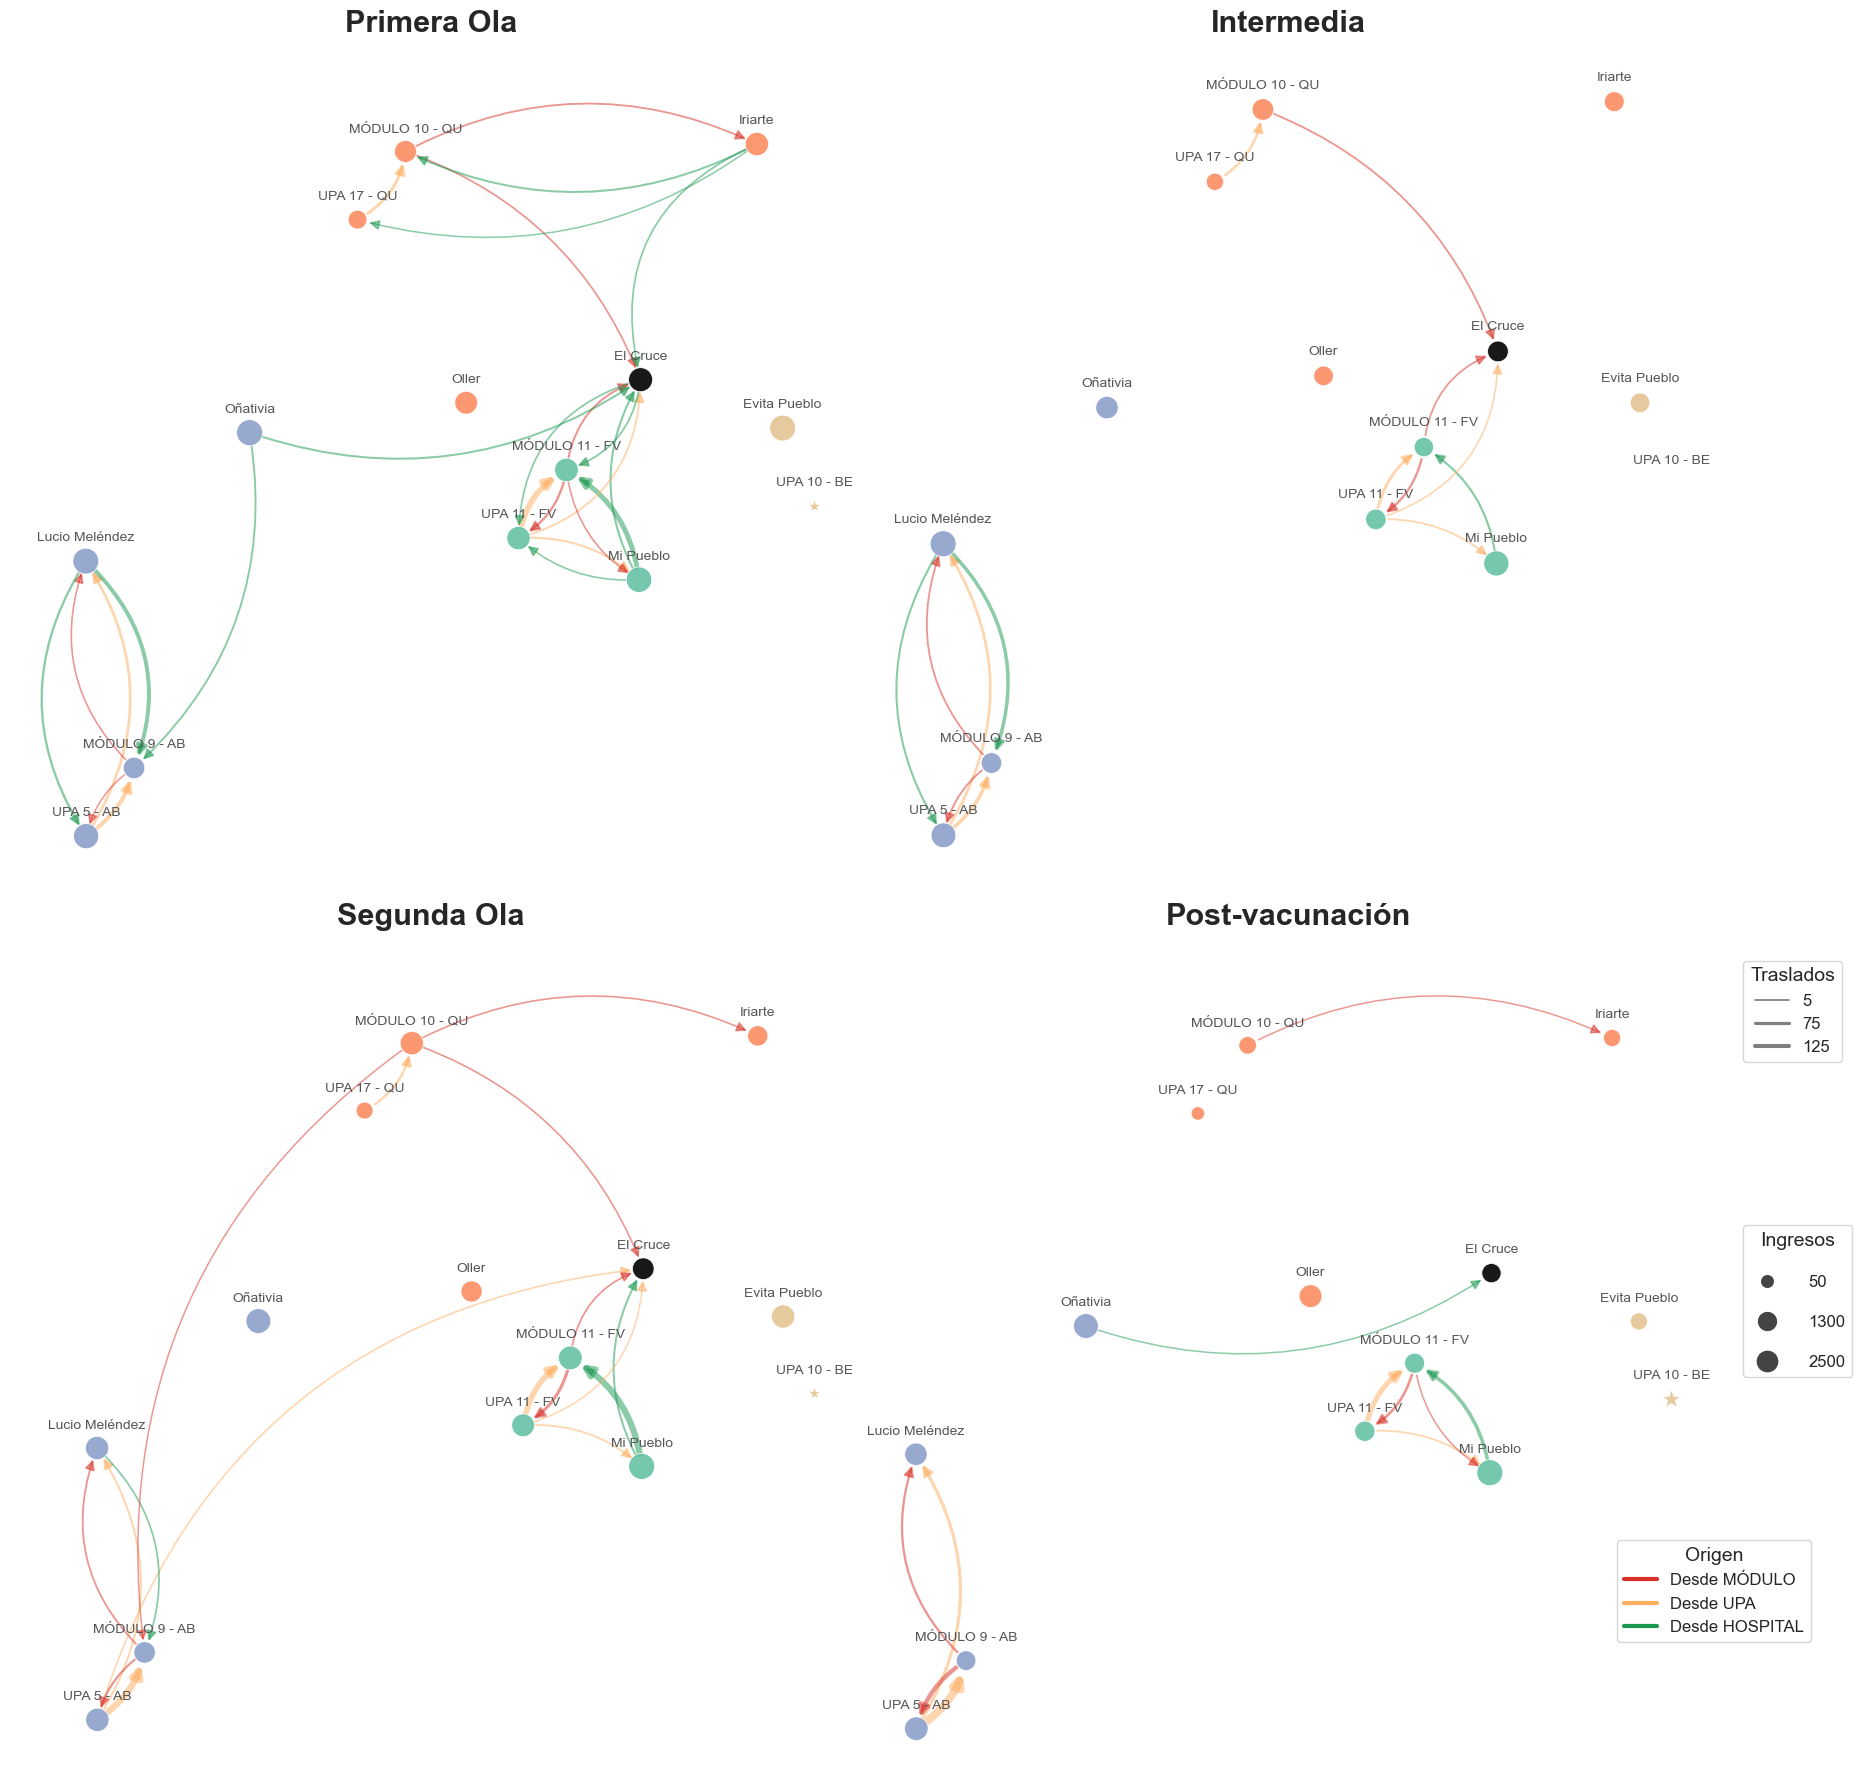

In [25]:
# GRÁFICO 1: GRILLA 2x2 PERIODOS
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(22, 18))
fig.patch.set_facecolor('white')
cfg_grilla = {'min_grosor': 0.5, 'max_grosor': 8.0, 'min_tamano': 80, 'max_tamano': 350, 'color_por_origen': True}

v_max_enc, i_max_enc = 0, 0
max_tras_glob = df_traslados.groupby(['hospital_ingreso', 'hospital_destino']).size().max()
max_ing_glob = pacientes['hospital_origen'].value_counts().max()

for idx, (titulo, inicio, fin) in enumerate(PERIODOS):
    ax = axes.flatten()[idx]
    ax.set_title(titulo, fontsize=22, fontweight='bold', pad=20)
    
    ingresos_ser = pacientes[pacientes['fecha_ingreso'].between(inicio, fin)]['hospital_origen'].value_counts()
    traslados_ser = df_traslados[df_traslados['fecha_egreso'].between(inicio, fin)].groupby(['hospital_ingreso', 'hospital_destino']).size()
    traslados_dib = traslados_ser[traslados_ser > 2].reset_index(name='peso')
    
    if not traslados_dib.empty: v_max_enc = max(v_max_enc, traslados_dib['peso'].max())
    if not ingresos_ser.empty: i_max_enc = max(i_max_enc, ingresos_ser.max())

    G = nx.DiGraph()
    for _, row in df_coordenadas.iterrows():
        n_ing = ingresos_ser.get(row['hospital'], 0)
        sz = aplicar_escala_visual(n_ing, ingresos_ser.max() if not ingresos_ser.empty else 1, cfg_grilla['min_tamano'], cfg_grilla['max_tamano'])
        G.add_node(row['hospital'], pos=(row['lon'], row['lat']), color=row.get('color_rgb', 'grey'), size=sz, shape=MAPA_FORMAS.get(row['shape'], 'o'), alpha=0.9 if n_ing > 0 else 0.4)
    
    for _, row_t in traslados_dib.iterrows():
        if row_t['hospital_ingreso'] in hospitales_conocidos and row_t['hospital_destino'] in hospitales_conocidos:
            G.add_edge(row_t['hospital_ingreso'], row_t['hospital_destino'], weight=row_t['peso'])

    dibujar_grafo_nx(ax, G, nx.get_node_attributes(G, 'pos'), max_tras_glob, max_ing_glob, cfg_grilla)

# Leyenda global
generar_leyendas(axes.flatten()[-1], redondear_estetico(v_max_enc), 50, redondear_estetico(i_max_enc), max_tras_glob, max_ing_glob, cfg_grilla, [(1.03, 1.0), (0.88, 0.30), (1.03, 0.68)])
plt.tight_layout(rect=[0, 0, 0.85, 1])
guardar_grafico_alta_calidad("grilla_traslados_periodos")
plt.show()

Gráficos exportados en: results/outputs/red


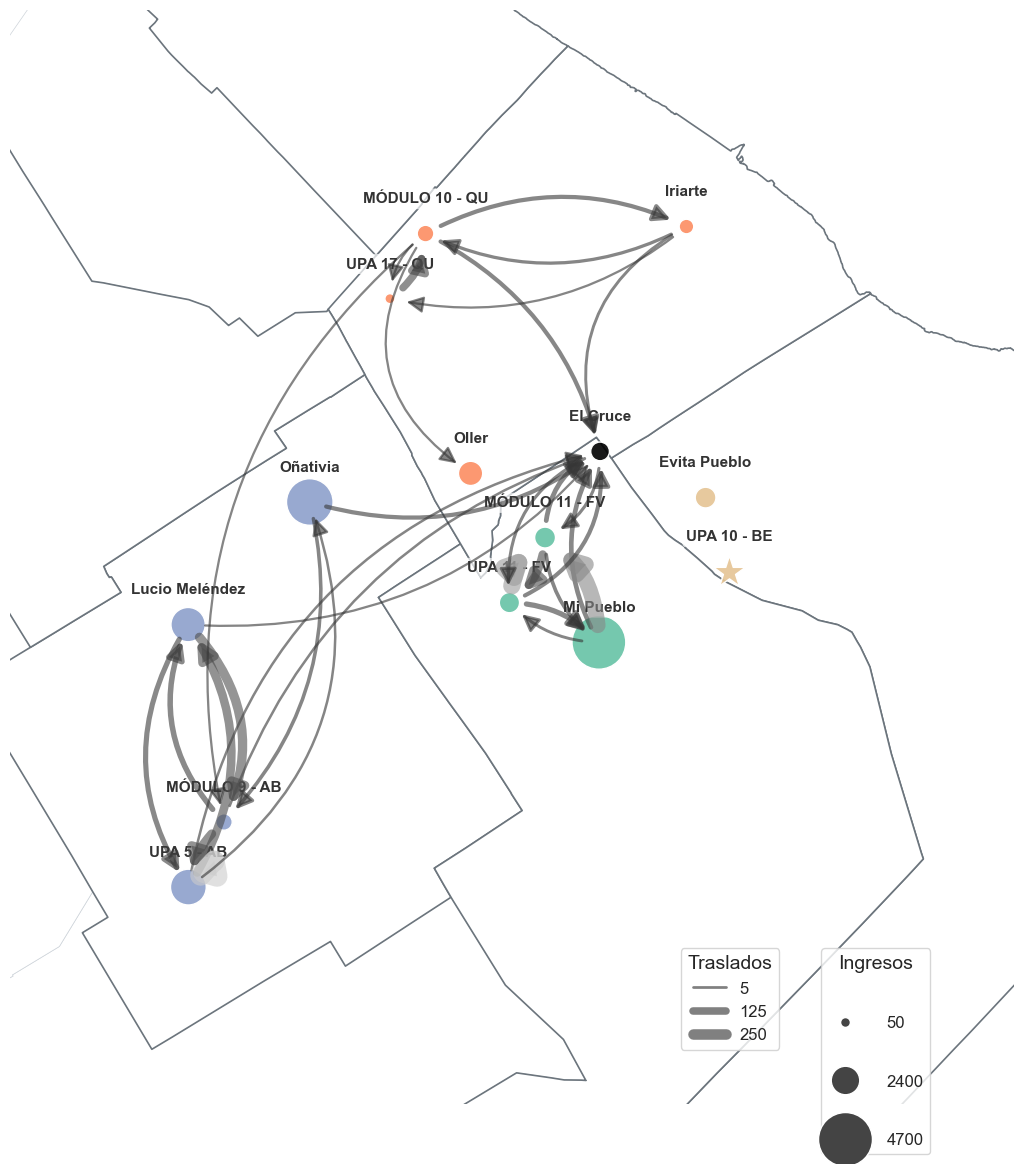

In [26]:
# GRÁFICO 2: MAPA GEOPANDAS
# ==========================================
fig, ax = plt.subplots(figsize=(16, 12))
fig.patch.set_facecolor('white')

ingresos_globales = pacientes['hospital_origen'].value_counts()
min_i_g = ingresos_globales.min() if not ingresos_globales.empty else 0

cfg_geo = {
    'min_grosor': 0.5, 'max_grosor': 15.0, 'min_tamano': 50, 'max_tamano': 1500,
    'escala_nodo': 'cuadratica', 'color_por_origen': False, 'alpha_arista': 0.6,
    'arrow_size': 25, 'node_size_edge': 600, 'lbl_offset': 0.008, 'lbl_size': 11,
    'lbl_weight': 'bold', 'lbl_color': '#333333', 'lbl_bbox': True, 'zorder_nodos': 5, 
    'zorder_aristas': 6, 'lw_nodos': 1.0,
    
    # RESTAURAMOS COMPORTAMIENTO ORIGINAL:
    'forzar_i_min_50': True,            # Mínimo de leyenda duro en 50
    'min_ingresos_real': min_i_g        # Para el cálculo matemático del área
}

# 1. Dibujar Fondo (GeoPandas)
deptos = gpd.read_file("../data/shapefiles/departamento/departamentoPolygon.shp")
pba = deptos[deptos["in1"].astype(str).str.startswith("06")].to_crs(epsg=4326)
sudeste = pba[pba["nam"].astype(str).str.upper().isin(["QUILMES", "ALMIRANTE BROWN", "FLORENCIO VARELA", "BERAZATEGUI", "LANUS", "LOMAS DE ZAMORA", "AVELLANEDA", "MORON", "ITUZAINGO"])]

pba.plot(ax=ax, color="#FFFFFF", edgecolor="#ced4da", linewidth=0.5, zorder=0)
sudeste.plot(ax=ax, color="#FFFFFF", edgecolor="#6c757d", linewidth=1.2, zorder=1)

# 2. Grafo
G_geo = nx.DiGraph()
max_i_g = ingresos_globales.max()
max_t_g = df_traslados.groupby(['hospital_ingreso', 'hospital_destino']).size().max()

for _, row in df_coordenadas.iterrows():
    cant = ingresos_globales.get(row['hospital'], 0)
    sz = aplicar_escala_visual(cant, max_i_g, cfg_geo['min_tamano'], cfg_geo['max_tamano'], 'cuadratica', min_valor=cfg_geo['min_ingresos_real'])
    G_geo.add_node(row['hospital'], pos=(row['lon'], row['lat']), color=row.get('color_rgb', 'grey'), size=sz, shape=MAPA_FORMAS.get(row['shape'], 'o'), alpha=0.9 if cant > 0 else 0.4)

tras_grp = df_traslados.groupby(['hospital_ingreso', 'hospital_destino']).size()
for (u, v), peso in tras_grp[tras_grp >= 3].items():
    if u in hospitales_conocidos and v in hospitales_conocidos: G_geo.add_edge(u, v, weight=peso)

dibujar_grafo_nx(ax, G_geo, nx.get_node_attributes(G_geo, 'pos'), max_t_g, max_i_g, cfg_geo)

# Zoom y Ajustes
ax.set_xlim(df_coordenadas['lon'].min() - 0.05, df_coordenadas['lon'].max() + 0.08)
ax.set_ylim(df_coordenadas['lat'].min() - 0.05, df_coordenadas['lat'].max() + 0.05)

# Pasamos los valores crudos a la leyenda; ahora la función se encarga estrictamente de redondearlos
cfg_geo['leg_dynamic_spc'] = True
generar_leyendas(ax, max_t_g, min_i_g, max_i_g, max_t_g, max_i_g, cfg_geo, [(0.66, 0.15), None, (0.80, 0.15)])

plt.tight_layout()
guardar_grafico_alta_calidad("mapa_red_traslados")
plt.show()

In [ ]:
# FUNCIONES AUXILIARES DE ESTADÍSTICA
# ==========================================
def agregar_etiquetas_grafico(ax, tipo='bar'):
    """ Agrega los números encima de las barras o los puntos """
    max_y = ax.get_ylim()[1]
    
    if tipo == 'bar' or tipo == 'stack':
        max_y_per_x = {}
        for p in ax.patches:
            h = p.get_height()
            if h > 0:
                x_c = p.get_x() + p.get_width() / 2.
                y_t = p.get_y() + h
                max_y_per_x[x_c] = max(max_y_per_x.get(x_c, 0), y_t)
        
        for x, top in max_y_per_x.items():
            if top >= (max_y * 0.02):
                ax.text(x, top * 1.1, f'{int(top)}', ha="center", va="bottom", fontsize=10, fontweight='bold', color='#333333')
    
    elif tipo == 'scatter':
        for c in ax.collections:
            for x, y in c.get_offsets():
                if y > 0: ax.text(x, y * 1.25, f'{int(y)}', ha="center", va="bottom", fontsize=10, fontweight='bold')
    
    ax.set_ylim(0.5 if ax.get_yscale() == 'log' else 0, max_y * 5 if ax.get_yscale() == 'log' else max_y * 1.1)


,Primera Ola,Intermedia,Segunda Ola,Post-vacunación
Días totales,153,120,153,518
Admisiones (Prom. diario),5944 (38.8),2839 (23.7),6193 (40.5),11347 (21.9)
Pacientes admitidos,5363,2558,5474,10601
Traslados totales (% admisiones),467 (7.9%),196 (6.9%),509 (8.2%),494 (4.4%)
Pacientes trasladados,438,176,490,438
Promedio diario de traslados,3.1,1.6,3.3,1.0
Traslados en ambulancia (% total),258 (55.2%),98 (50.0%),194 (38.1%),91 (18.4%)
Traslados UPA-Módulos,270,142,358,454
Rutas UPA-Módulos,13,11,14,9
Rutas totales | Ambulancia,25 | 20,14 | 9,17 | 12,11 | 7


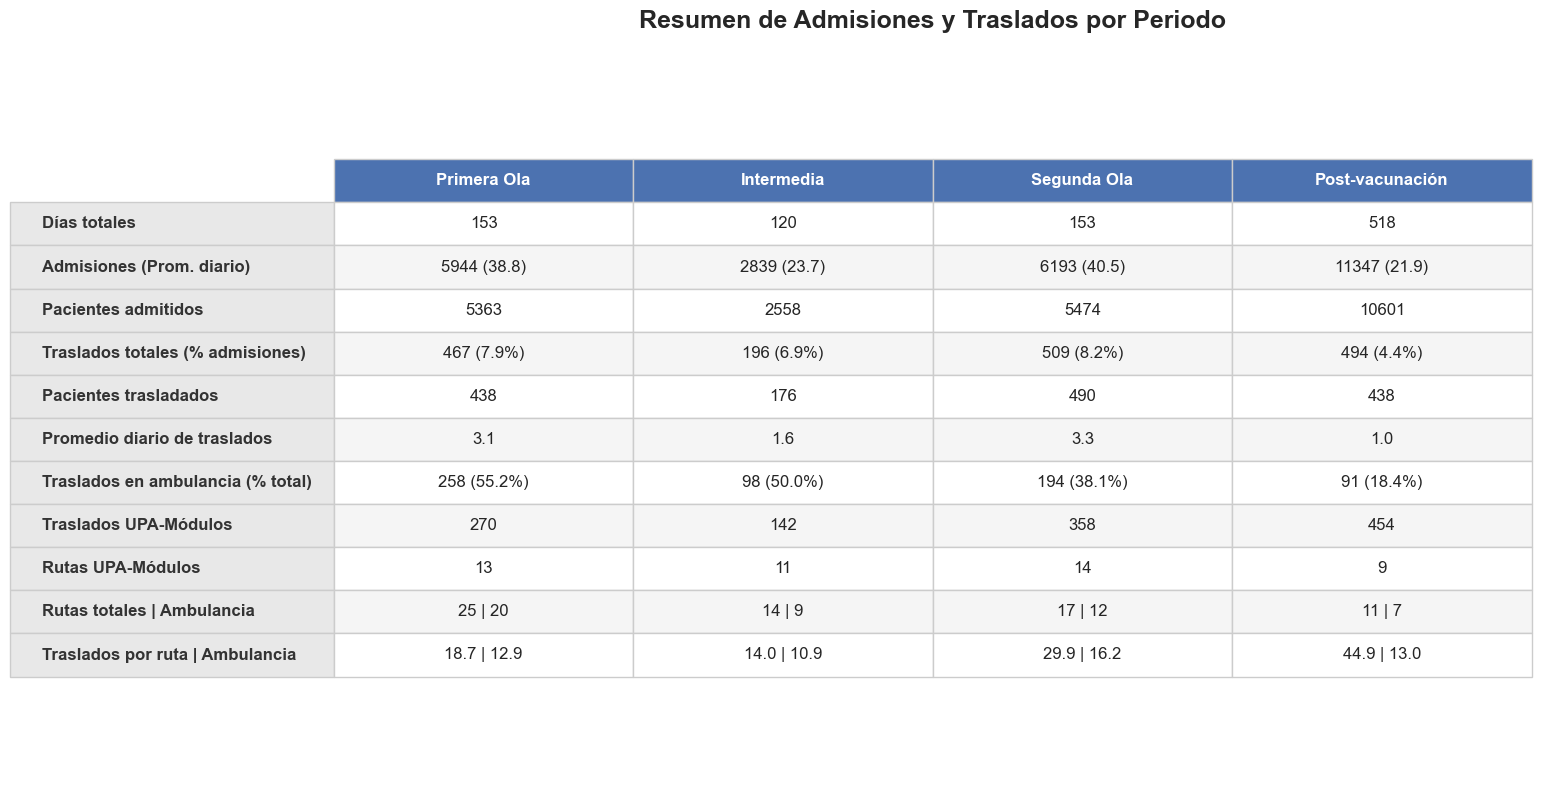

In [22]:
# 7. GENERACIÓN DE TABLA RESUMEN (MÉTRICAS)
# ==========================================
PAREJAS_MISMO_PREDIO = [
    {'UPA 17 - QU', 'Módulo Hospitalario 10 - QU'},
    {'UPA 11 - FV', 'Módulo Hospitalario 11 - FV'},
    {'UPA 5 - AB', 'Módulo Hospitalario 9 - AB'}
]

def requiere_ambulancia(row):
    return {row['hospital_ingreso'], row['hospital_destino']} not in PAREJAS_MISMO_PREDIO

def es_upa_o_modulo(nombre):
    n = str(nombre).upper()
    return 'UPA' in n or 'MÓDULO' in n or 'MODULO' in n

df_traslados['es_ambulancia'] = df_traslados.apply(requiere_ambulancia, axis=1)

def generar_tabla_resumen(pacientes_df, traslados_df, periodos, hospitales_conocidos):
    columnas_tabla = {}
    
    for titulo, inicio, fin in periodos:
        fecha_ini, fecha_fin = pd.to_datetime(inicio), pd.to_datetime(fin)
        total_days = (fecha_fin - fecha_ini).days + 1
        
        # Admisiones
        df_p_per = pacientes_df[pacientes_df['fecha_ingreso'].between(inicio, fin)]
        admissions = len(df_p_per)
        pacientes_admitidos_unicos = df_p_per['paciente_id'].nunique()
        
        # Traslados Válidos (filtrando self-loops y no conocidos, igual que el mapa)
        df_t_bruto = traslados_df[traslados_df['fecha_egreso'].between(inicio, fin)]
        mask_validos = (df_t_bruto['hospital_ingreso'].isin(hospitales_conocidos)) & (df_t_bruto['hospital_destino'].isin(hospitales_conocidos)) & (df_t_bruto['hospital_ingreso'] != df_t_bruto['hospital_destino'])
        df_t_limpio = df_t_bruto[mask_validos]
        
        pesos_rutas = df_t_limpio.groupby(['hospital_ingreso', 'hospital_destino']).size().reset_index(name='peso')
        rutas_dibujables = pesos_rutas[pesos_rutas['peso'] > 2]
        df_t_periodo = df_t_limpio.merge(rutas_dibujables[['hospital_ingreso', 'hospital_destino']], on=['hospital_ingreso', 'hospital_destino'])
        
        total_transfers = len(df_t_periodo)
        df_amb_periodo = df_t_periodo[df_t_periodo['es_ambulancia']]
        amb_transfers = len(df_amb_periodo)
        
        edges_totales = df_t_periodo[['hospital_ingreso', 'hospital_destino']].drop_duplicates().shape[0]
        edges_amb = df_amb_periodo[['hospital_ingreso', 'hospital_destino']].drop_duplicates().shape[0]
        
        df_refuerzo = df_t_periodo[df_t_periodo['hospital_ingreso'].apply(es_upa_o_modulo)]
        
        columnas_tabla[titulo] = {
            'Días totales': f"{total_days}",
            'Admisiones (Prom. diario)': f"{admissions} ({admissions/total_days if total_days>0 else 0:.1f})",
            'Pacientes admitidos': f"{pacientes_admitidos_unicos}",
            'Traslados totales (% admisiones)': f"{total_transfers} ({(total_transfers/admissions*100) if admissions>0 else 0:.1f}%)",
            'Pacientes trasladados': f"{df_t_periodo['paciente_id'].nunique()}",
            'Promedio diario de traslados': f"{total_transfers/total_days if total_days>0 else 0:.1f}",
            'Traslados en ambulancia (% total)': f"{amb_transfers} ({(amb_transfers/total_transfers*100) if total_transfers>0 else 0:.1f}%)",
            'Traslados UPA-Módulos': f"{len(df_refuerzo)}",
            'Rutas UPA-Módulos': f"{df_refuerzo[['hospital_ingreso', 'hospital_destino']].drop_duplicates().shape[0]}",
            'Rutas totales | Ambulancia': f"{edges_totales} | {edges_amb}",
            'Traslados por ruta | Ambulancia': f"{total_transfers/edges_totales if edges_totales>0 else 0:.1f} | {amb_transfers/edges_amb if edges_amb>0 else 0:.1f}"
        }

    orden_filas = ['Días totales', 'Admisiones (Prom. diario)', 'Pacientes admitidos', 'Traslados totales (% admisiones)', 'Pacientes trasladados', 'Promedio diario de traslados', 'Traslados en ambulancia (% total)', 'Traslados UPA-Módulos', 'Rutas UPA-Módulos', 'Rutas totales | Ambulancia', 'Traslados por ruta | Ambulancia']
    return pd.DataFrame(columnas_tabla).loc[orden_filas]

def exportar_tabla_estetica(tabla_df):
    """ Dibuja la tabla con Matplotlib y exporta a LaTeX """
    # 1. LaTeX
    latex_code = tabla_df.reset_index().style.format(escape="latex").hide(axis="index").to_latex(
        buf="results/outputs/red/tabla_resumen.tex", column_format='l' + 'c' * len(tabla_df.columns), hrules=True
    )
    
    # 2. Matplotlib
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.axis('tight'); ax.axis('off')
    tabla_mpl = ax.table(cellText=tabla_df.values, rowLabels=tabla_df.index, colLabels=tabla_df.columns, loc='center', cellLoc='center')
    
    tabla_mpl.auto_set_font_size(False)
    tabla_mpl.set_fontsize(12)
    tabla_mpl.scale(1.2, 2.2)

    for (row, col), cell in tabla_mpl.get_celld().items():
        cell.set_edgecolor('#cccccc')
        if row == 0: cell.set_facecolor('#4c72b0'); cell.set_text_props(weight='bold', color='white')
        elif col == -1: cell.set_facecolor('#e8e8e8'); cell.set_text_props(weight='bold', color='#333333'); cell._loc = 'left'
        else: cell.set_facecolor('#f5f5f5' if row % 2 == 0 else '#ffffff')

    plt.title("Resumen de Admisiones y Traslados por Periodo", fontsize=18, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

# EJECUCIÓN SECCIÓN 7
tabla_resumen = generar_tabla_resumen(pacientes, df_traslados, PERIODOS, hospitales_conocidos)
display(tabla_resumen)
exportar_tabla_estetica(tabla_resumen)


C:\Users\micag\AppData\Local\Temp\ipykernel_36204\1567740880.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


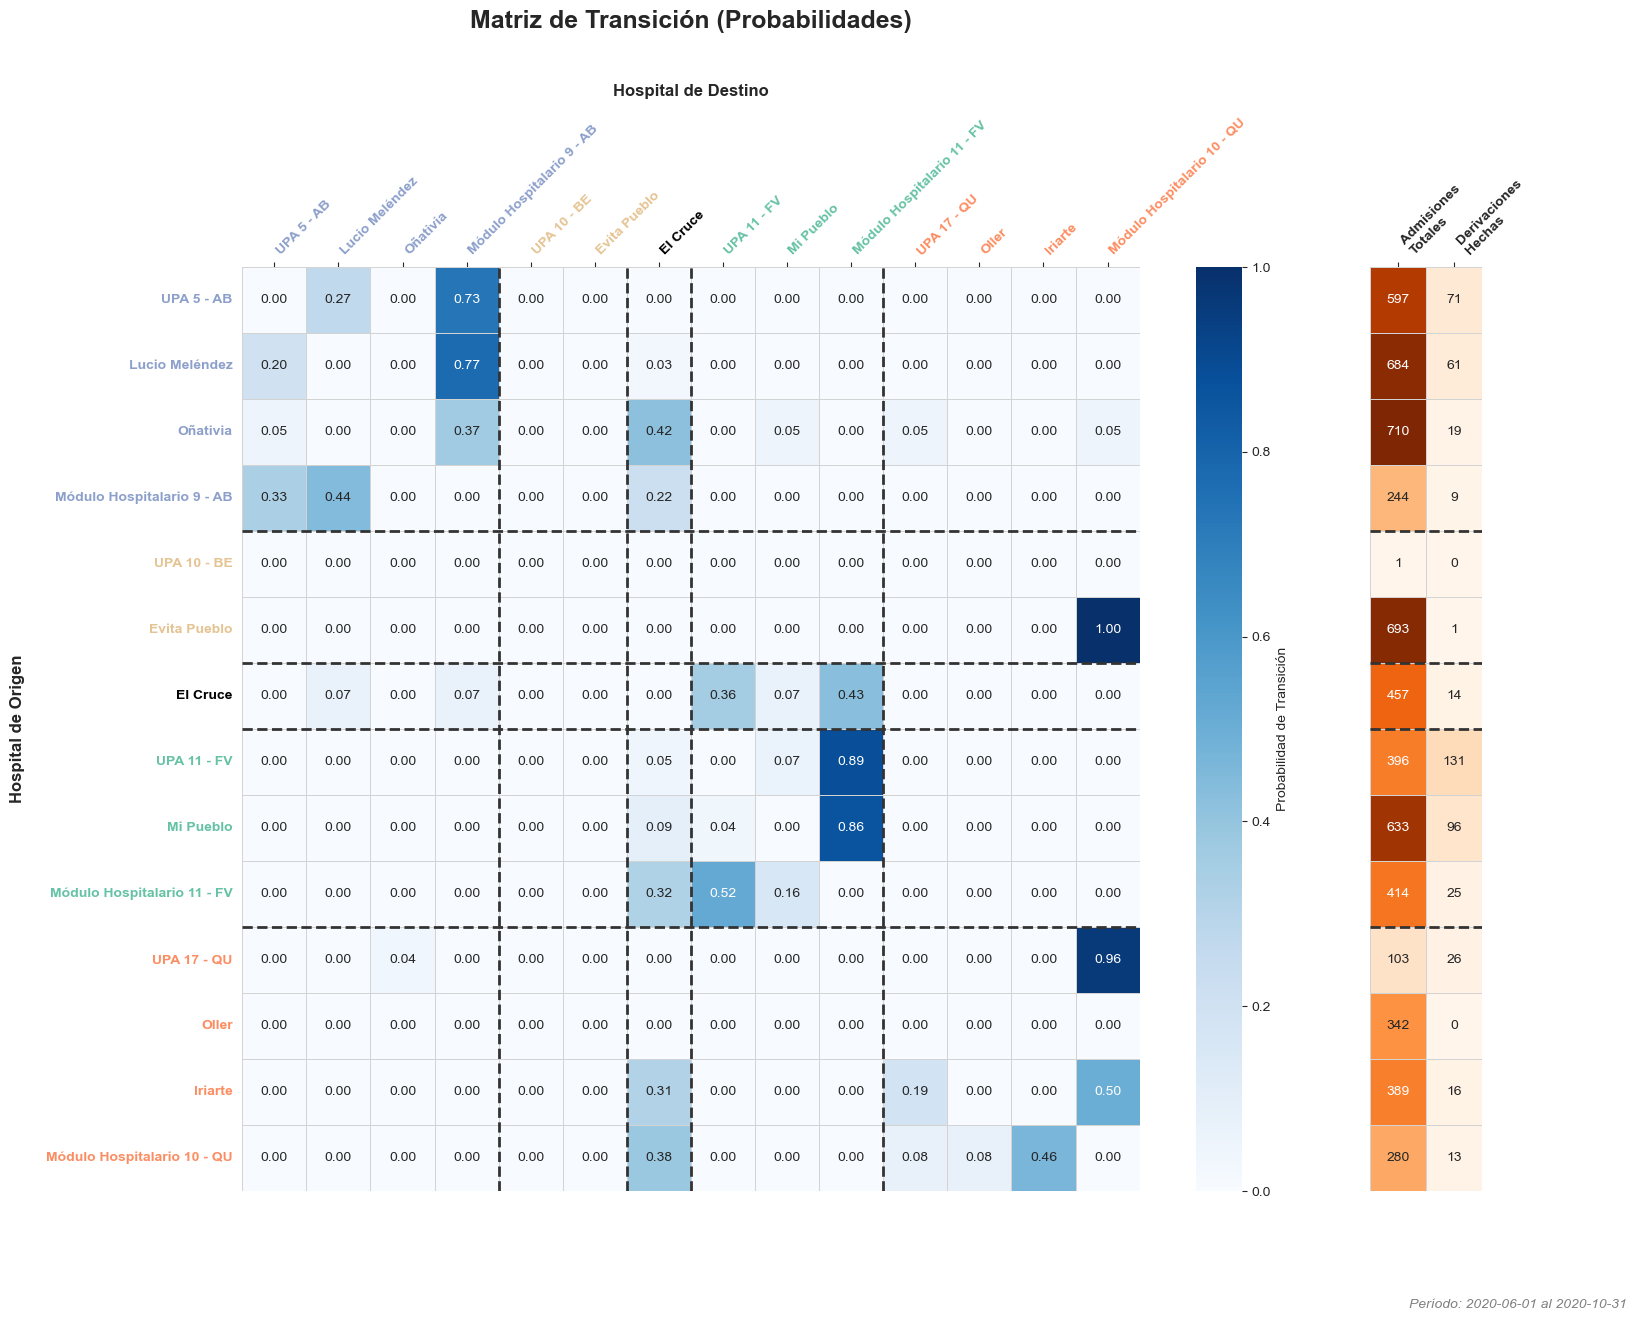

C:\Users\micag\AppData\Local\Temp\ipykernel_36204\1567740880.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


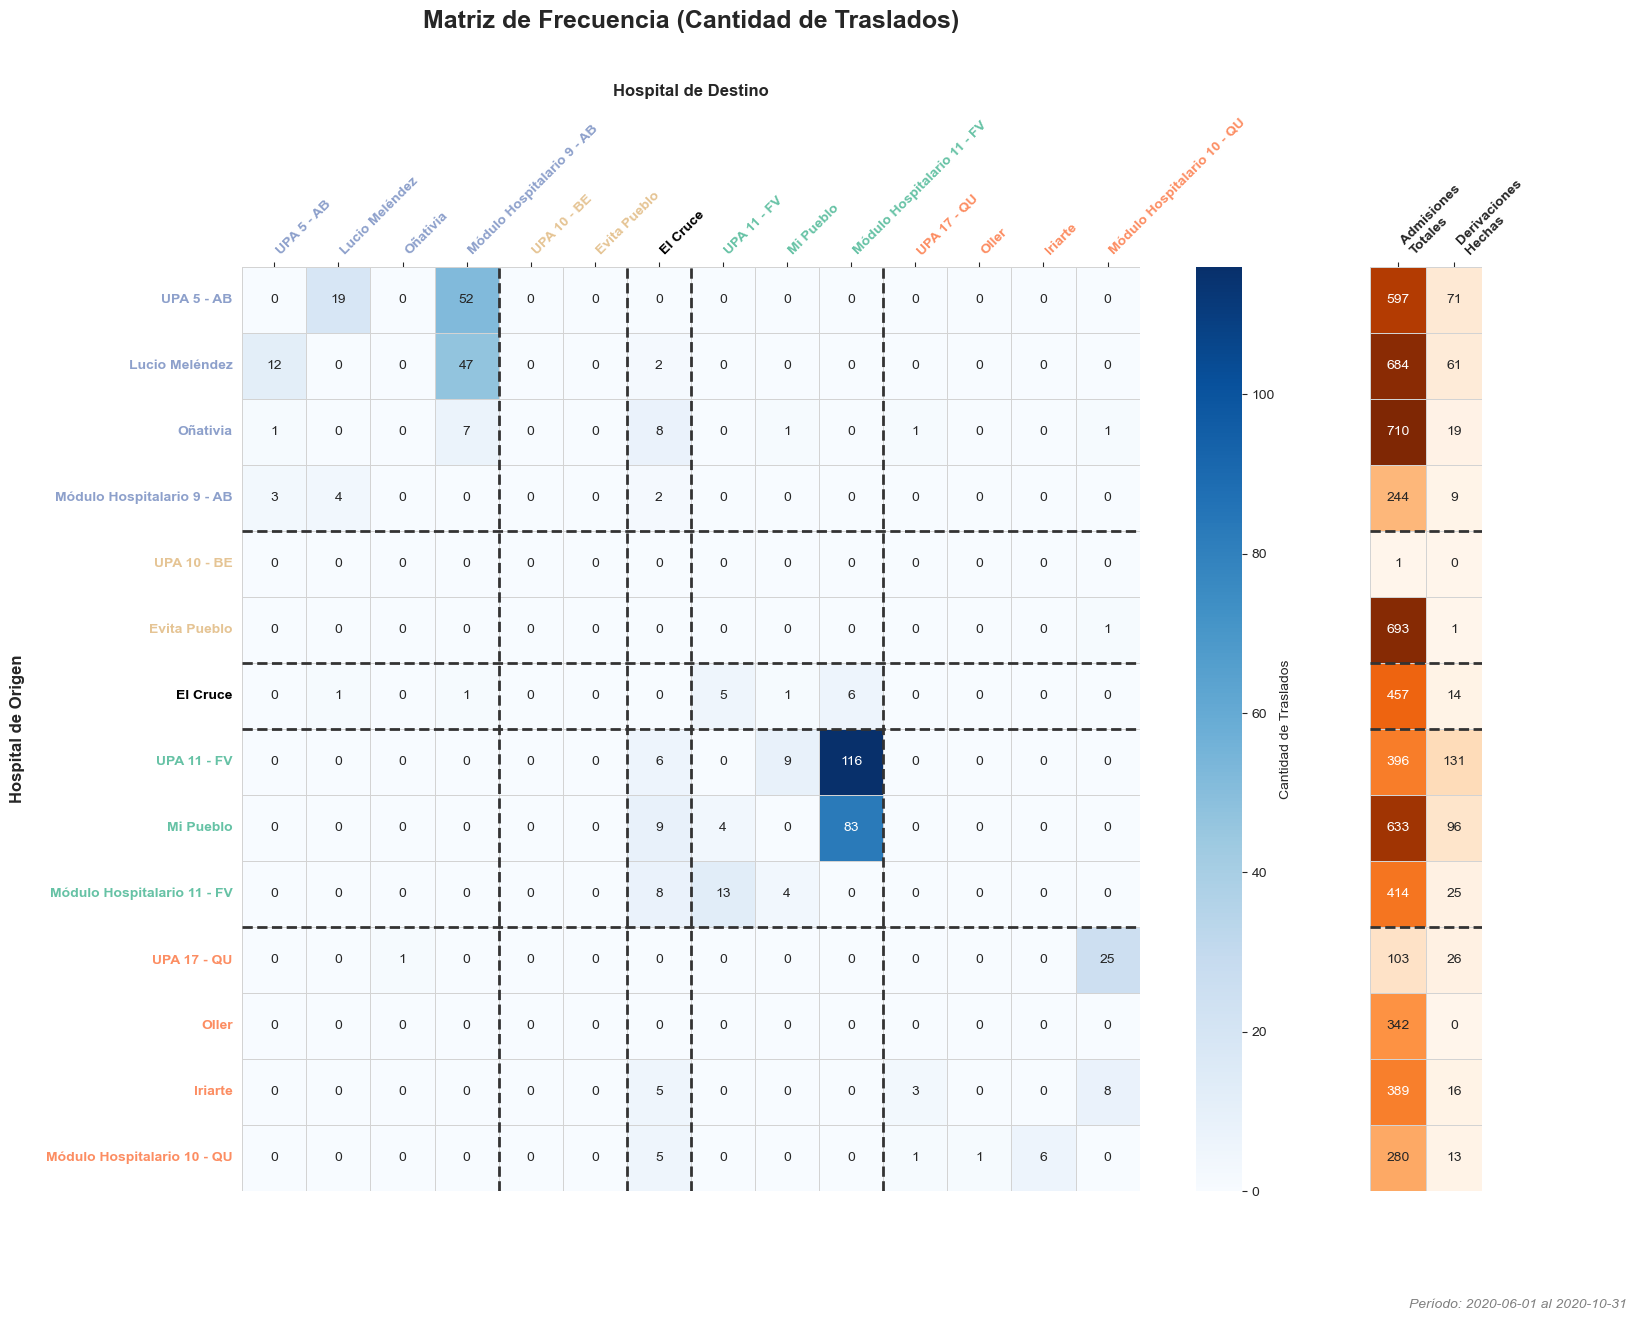

In [23]:
# 8. GENERACIÓN DE MATRICES
# ==============================================================================
def generar_matrices_traslados(traslados_df, pacientes_df, hospitales_df, fecha_inicio, fecha_fin, tipo_matriz='probabilidad'):
    df_meta = hospitales_df[['Nombre Hospital', 'municipioAbreviado', 'complejidad', 'color']].copy()
    df_meta['color'] = df_meta['color'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    df_meta_red = df_meta[df_meta['Nombre Hospital'].isin(set(hospitales_df['Nombre Hospital']))].sort_values(['municipioAbreviado', 'complejidad'])

    orden_hospitales = df_meta_red['Nombre Hospital'].tolist()
    municipios_ordenados = df_meta_red['municipioAbreviado'].tolist()
    
    mask_tras = (traslados_df['fecha_egreso'].between(fecha_inicio, fecha_fin))
    df_t_periodo = traslados_df[mask_tras].copy()
    mask_validos = (df_t_periodo['hospital_ingreso'].isin(orden_hospitales)) & (df_t_periodo['hospital_destino'].isin(orden_hospitales)) & (df_t_periodo['hospital_ingreso'] != df_t_periodo['hospital_destino'])
    df_t_limpio = df_t_periodo[mask_validos].copy()
    
    df_p_periodo = pacientes_df[pacientes_df['fecha_ingreso'].between(fecha_inicio, fecha_fin)]

    # Totales
    total_admisiones = df_p_periodo.groupby('hospital_origen').size().reindex(orden_hospitales, fill_value=0)
    total_derivaciones_hechas = df_t_limpio.groupby('hospital_ingreso').size().reindex(orden_hospitales, fill_value=0)

    # Matriz
    matriz_frecuencias = pd.crosstab(df_t_limpio['hospital_ingreso'], df_t_limpio['hospital_destino']).reindex(index=orden_hospitales, columns=orden_hospitales, fill_value=0)
    
    if tipo_matriz == 'probabilidad':
        matriz_dibujo = matriz_frecuencias.div(matriz_frecuencias.sum(axis=1), axis=0).fillna(0)
        fmt_matriz, label_colorbar, titulo_base = ".2f", 'Probabilidad de Transición', "Matriz de Transición (Probabilidades)"
    else:
        matriz_dibujo = matriz_frecuencias
        fmt_matriz, label_colorbar, titulo_base = "d", 'Cantidad de Traslados', "Matriz de Frecuencia (Cantidad de Traslados)"

    fig = plt.figure(figsize=(16, 12))
    fig.patch.set_facecolor('white')
    gs = gridspec.GridSpec(1, 2, width_ratios=[12, 1.2], wspace=0.01) 

    ax_matriz = plt.subplot(gs[0])
    ax_totales = plt.subplot(gs[1])

    sns.heatmap(matriz_dibujo, annot=True, cmap="Blues", fmt=fmt_matriz, linewidths=0.5, linecolor='lightgray', cbar_kws={'label': label_colorbar}, ax=ax_matriz)
    
    df_totales_plot = pd.DataFrame({'Admisiones\nTotales': total_admisiones.values, 'Derivaciones\nHechas': total_derivaciones_hechas.values}, index=orden_hospitales)
    sns.heatmap(df_totales_plot, annot=True, cmap="Oranges", fmt="d", linewidths=0.5, linecolor='lightgray', cbar=False, ax=ax_totales)

    # Estética Ejes
    ax_matriz.xaxis.tick_top(); ax_matriz.xaxis.set_label_position('top') 
    ax_matriz.set_title(titulo_base, fontsize=18, fontweight='bold', pad=40)
    ax_matriz.set_xlabel("Hospital de Destino", fontsize=12, fontweight='bold', labelpad=15)
    ax_matriz.set_ylabel("Hospital de Origen", fontsize=12, fontweight='bold', labelpad=15)

    ax_totales.xaxis.tick_top(); ax_totales.xaxis.set_label_position('top'); ax_totales.set_ylabel("") 
    
    dict_colores = dict(zip(df_meta_red['Nombre Hospital'], df_meta_red['color']))
    for ax in [ax_matriz, ax_totales]:
        for tick_label in ax.get_xticklabels():
            hosp_name = tick_label.get_text()
            if ax == ax_matriz: tick_label.set_color(dict_colores.get(hosp_name, 'black'))
            tick_label.set_fontweight('bold'); tick_label.set_rotation(45); tick_label.set_ha('left') 
    
    for tick_label in ax_matriz.get_yticklabels():
        tick_label.set_color(dict_colores.get(tick_label.get_text(), 'black'))
        tick_label.set_fontweight('bold')

    ax_totales.set_yticklabels([]); ax_totales.tick_params(axis='y', which='both', length=0) 

    cambios_municipio = [i for i in range(1, len(municipios_ordenados)) if municipios_ordenados[i] != municipios_ordenados[i-1]]
    for c in cambios_municipio:
        ax_matriz.axhline(c, color='#333333', lw=2, linestyle='--'); ax_totales.axhline(c, color='#333333', lw=2, linestyle='--')
        ax_matriz.axvline(c, color='#333333', lw=2, linestyle='--') 

    plt.tight_layout()
    plt.figtext(0.99, 0.01, f"Período: {fecha_inicio} al {fecha_fin}", horizontalalignment='right', verticalalignment='bottom', fontsize=10, color='gray', style='italic')
    plt.show()

# EJECUCIÓN SECCIÓN 8
ini_estudio, fin_estudio = PERIODOS[0][1], PERIODOS[0][2]
generar_matrices_traslados(df_traslados, pacientes, hospitales, ini_estudio, fin_estudio, 'probabilidad')
generar_matrices_traslados(df_traslados, pacientes, hospitales, ini_estudio, fin_estudio, 'cantidad')



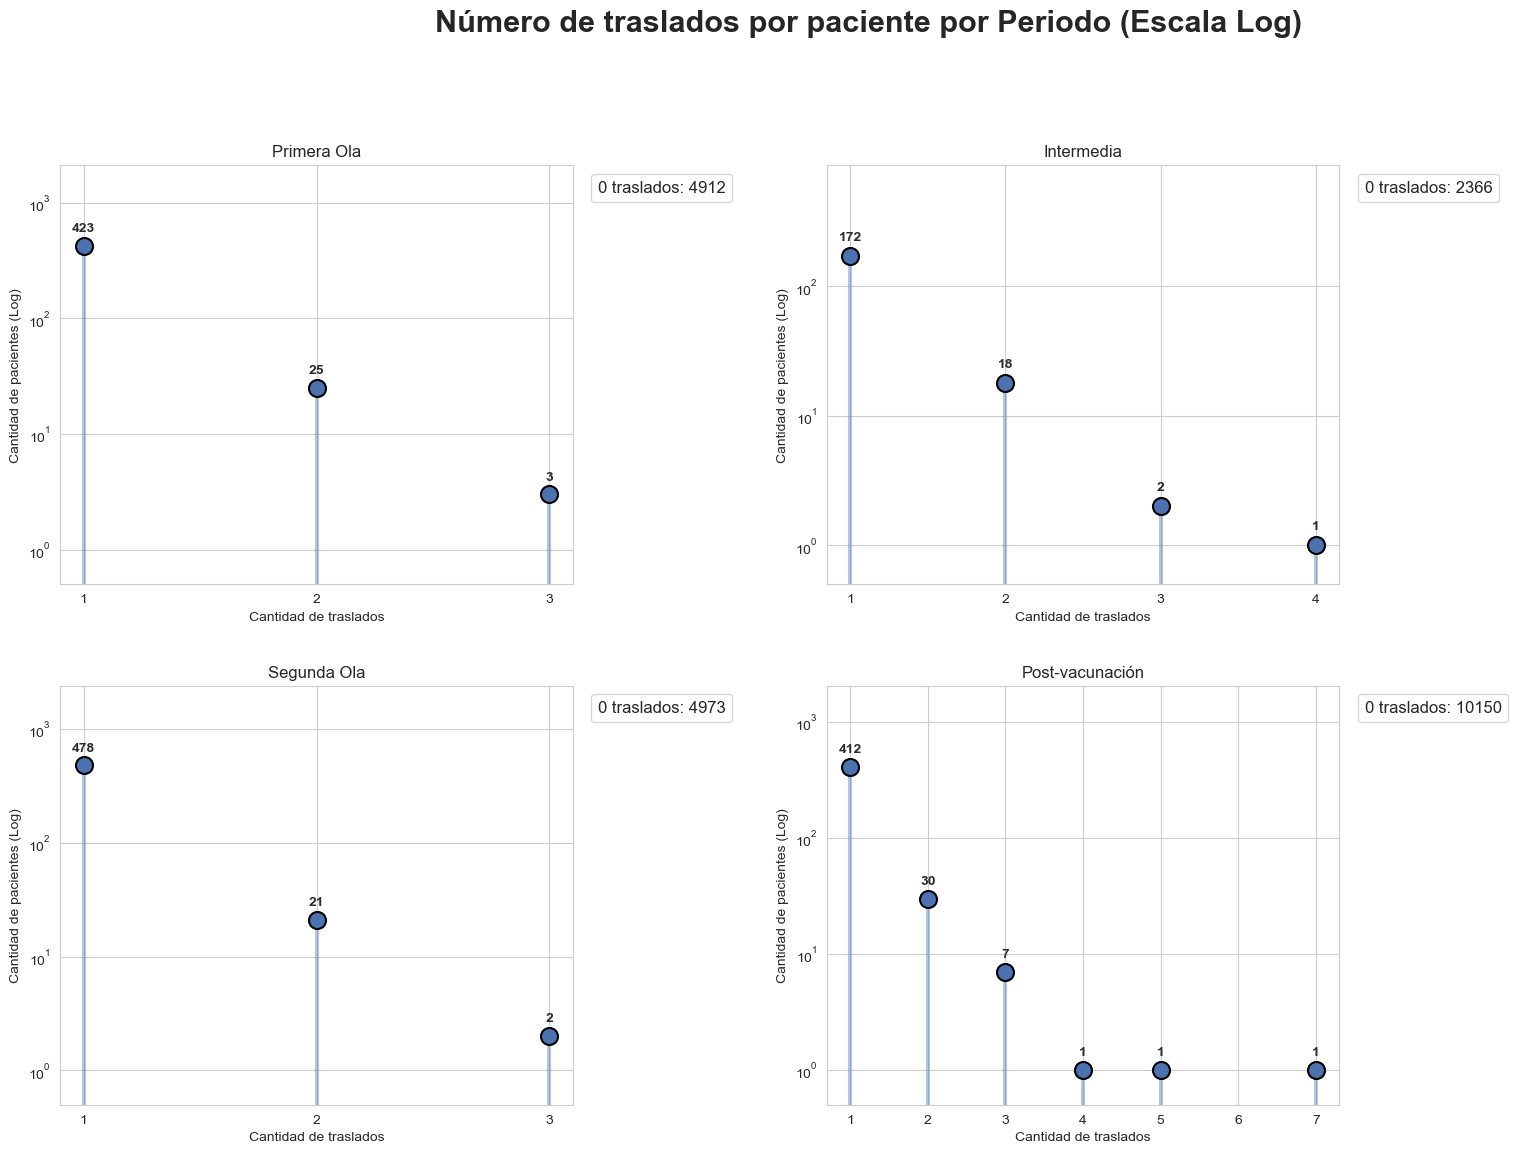

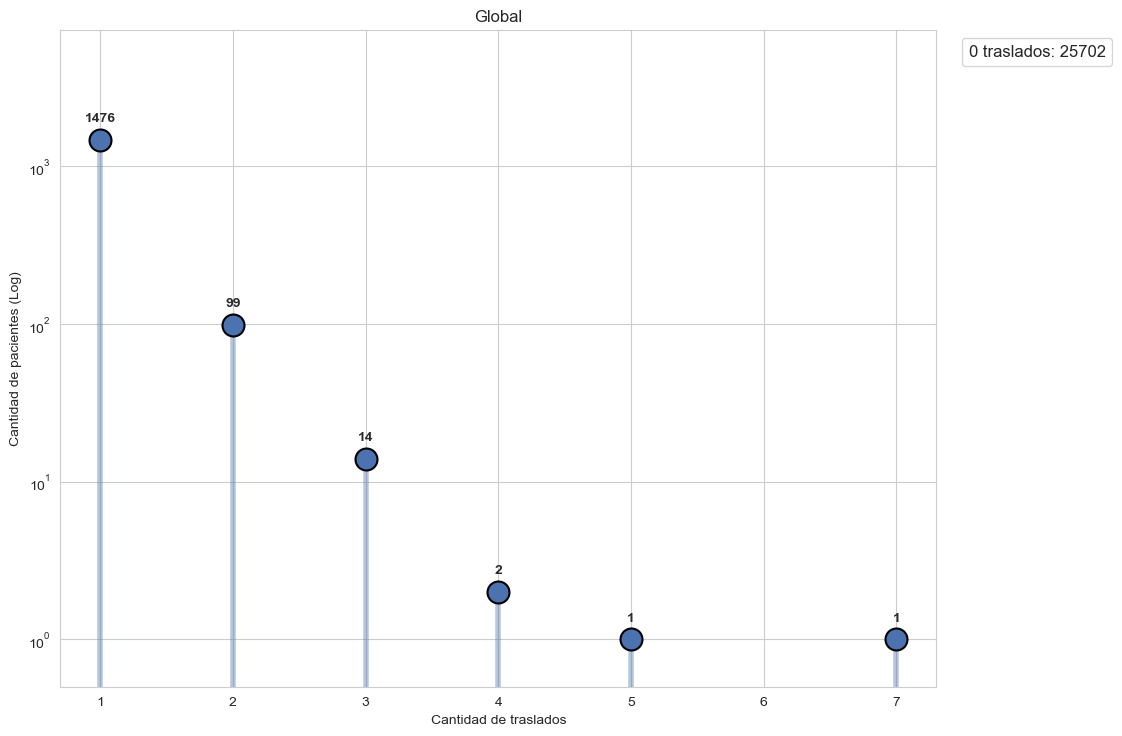

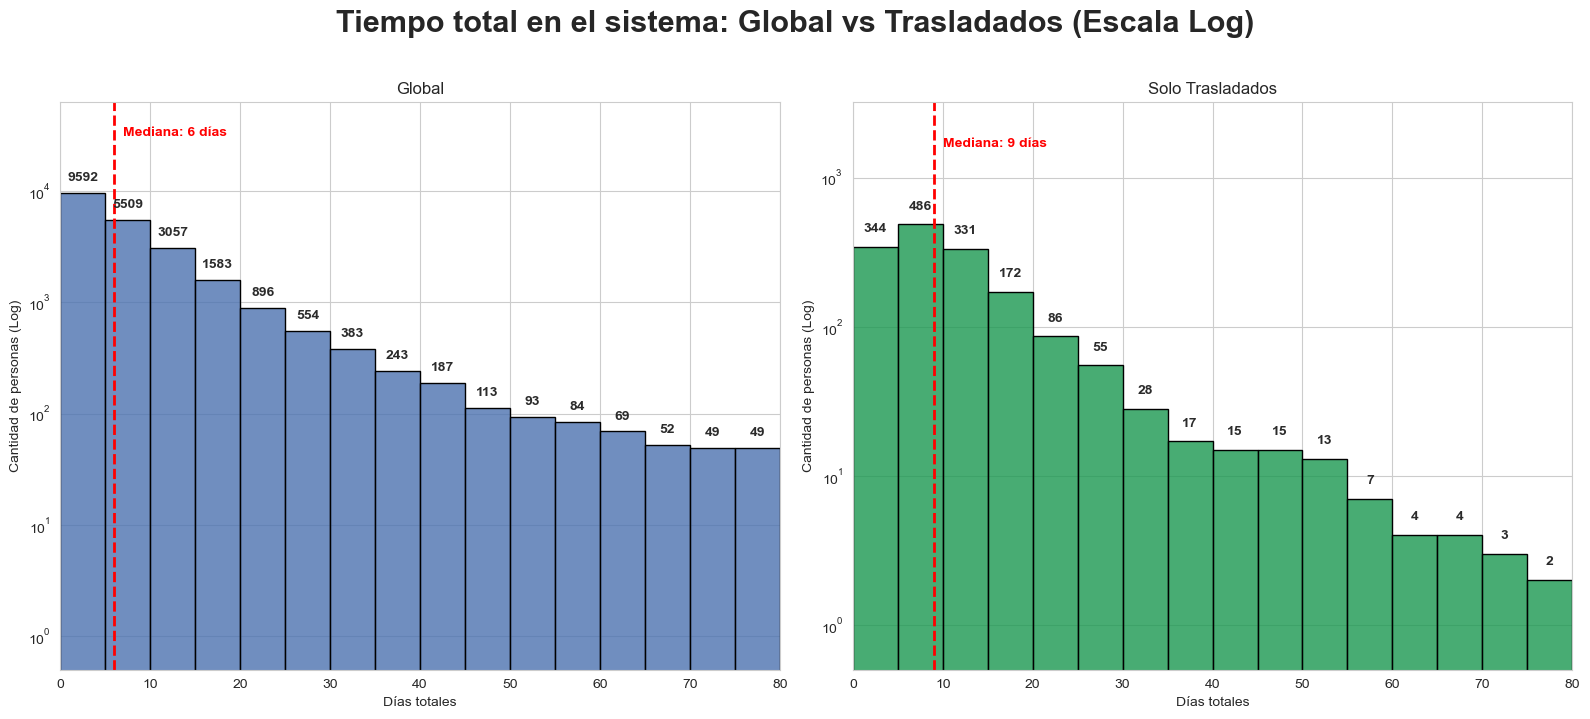

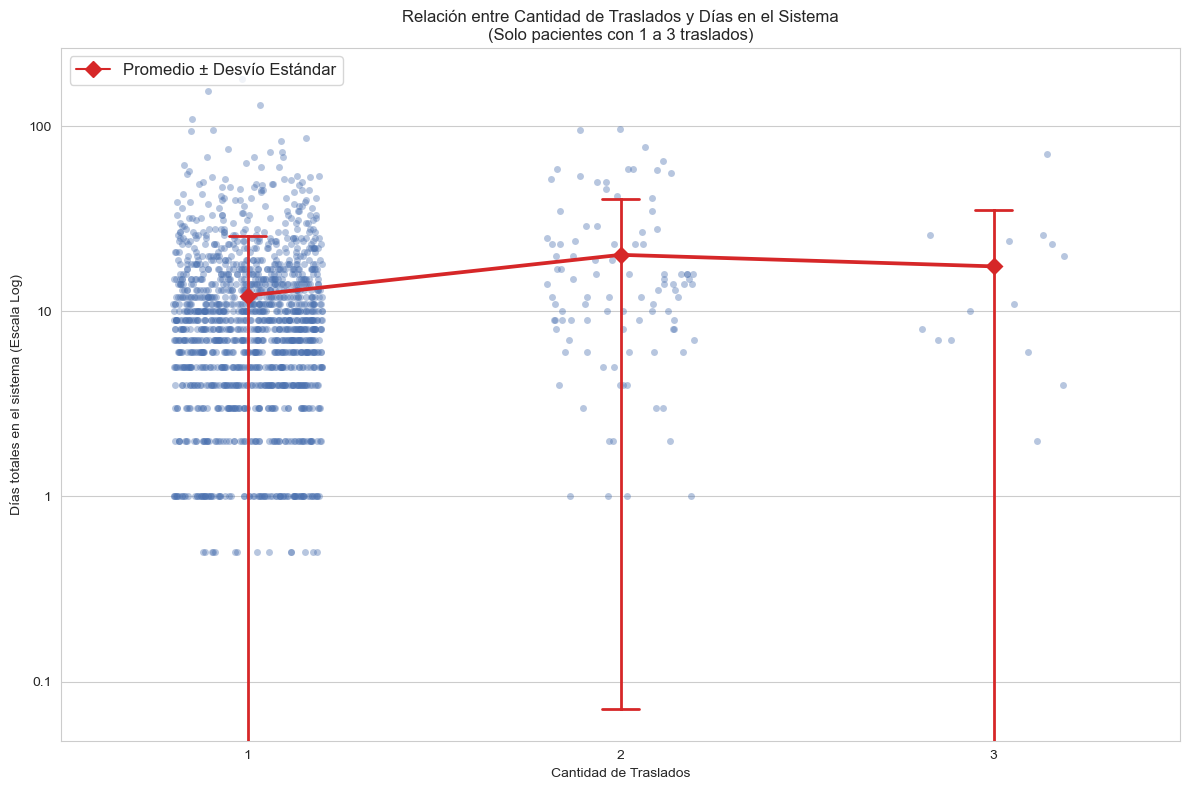

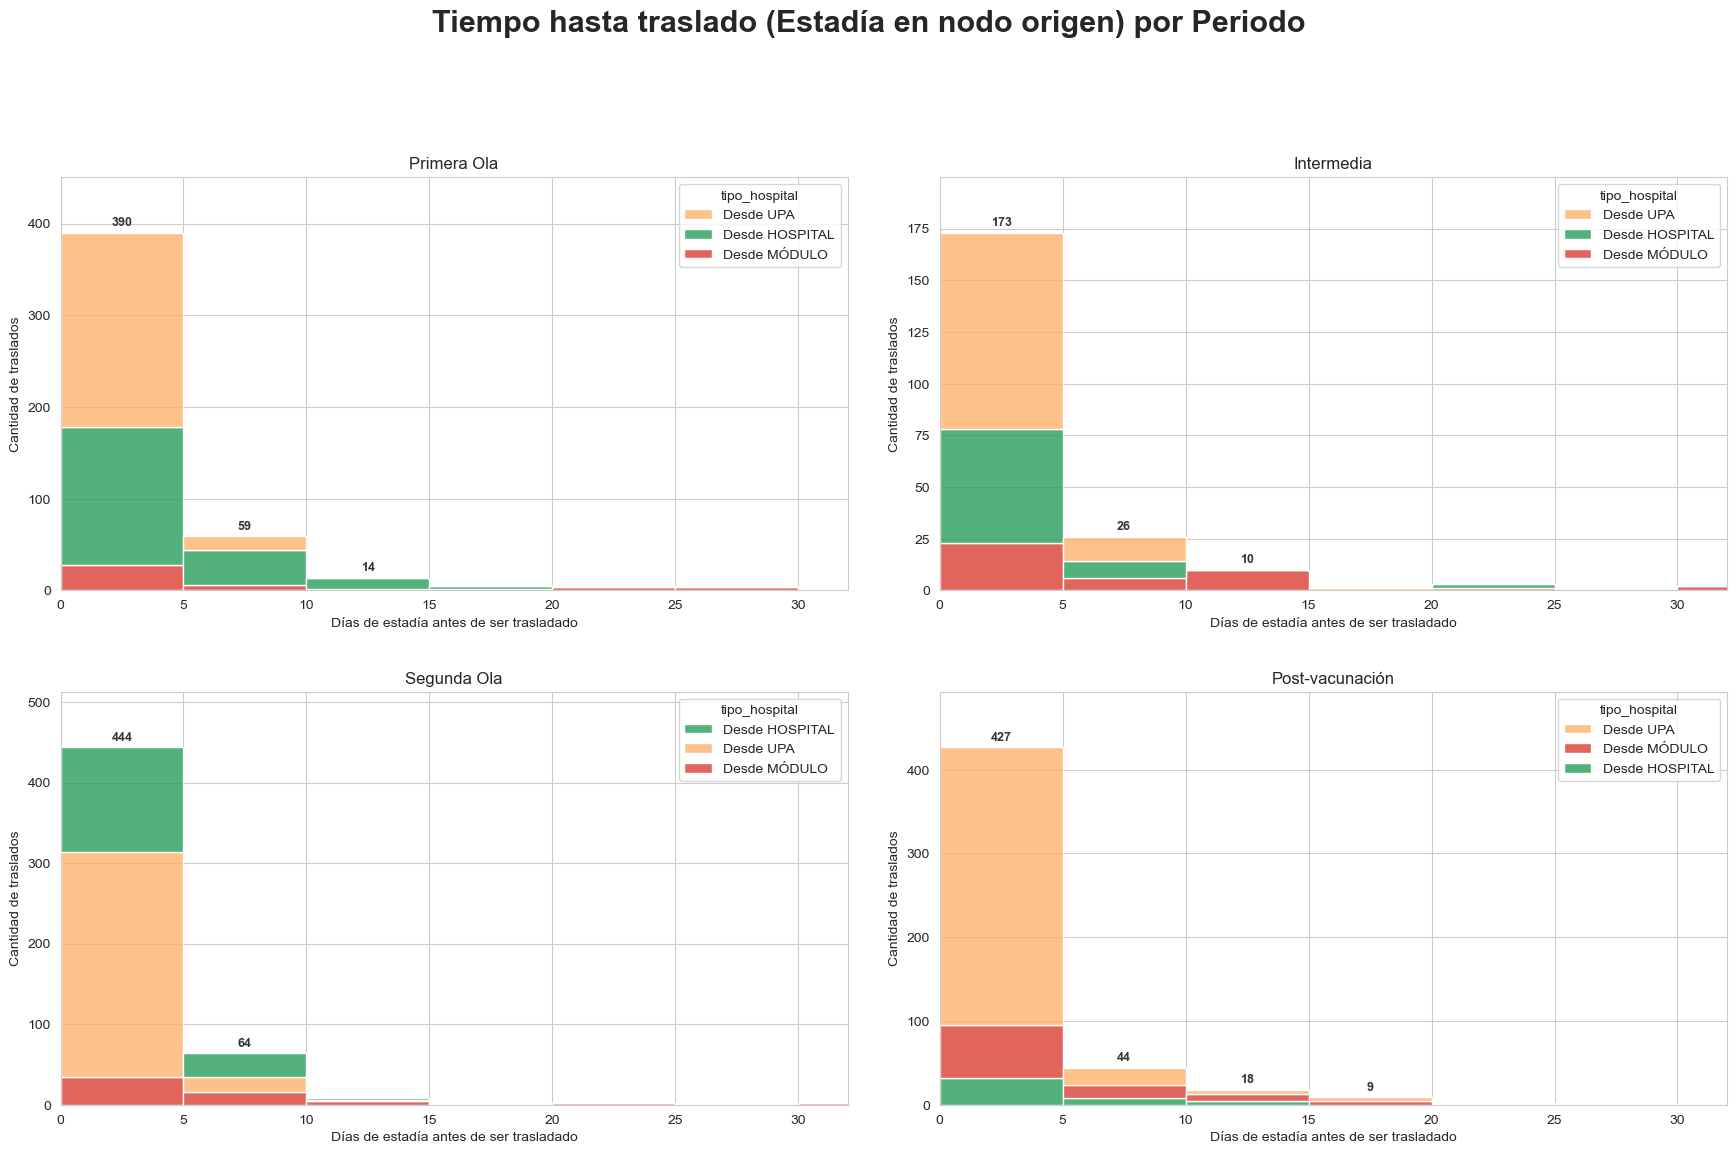

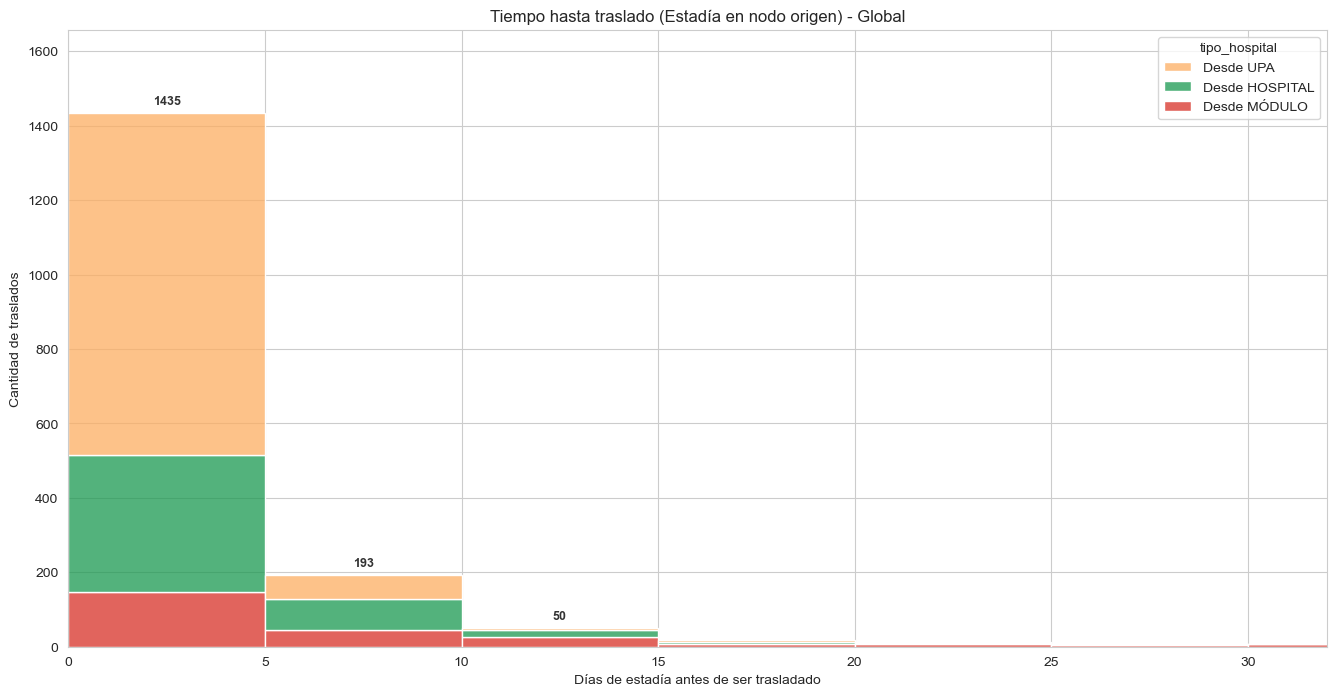

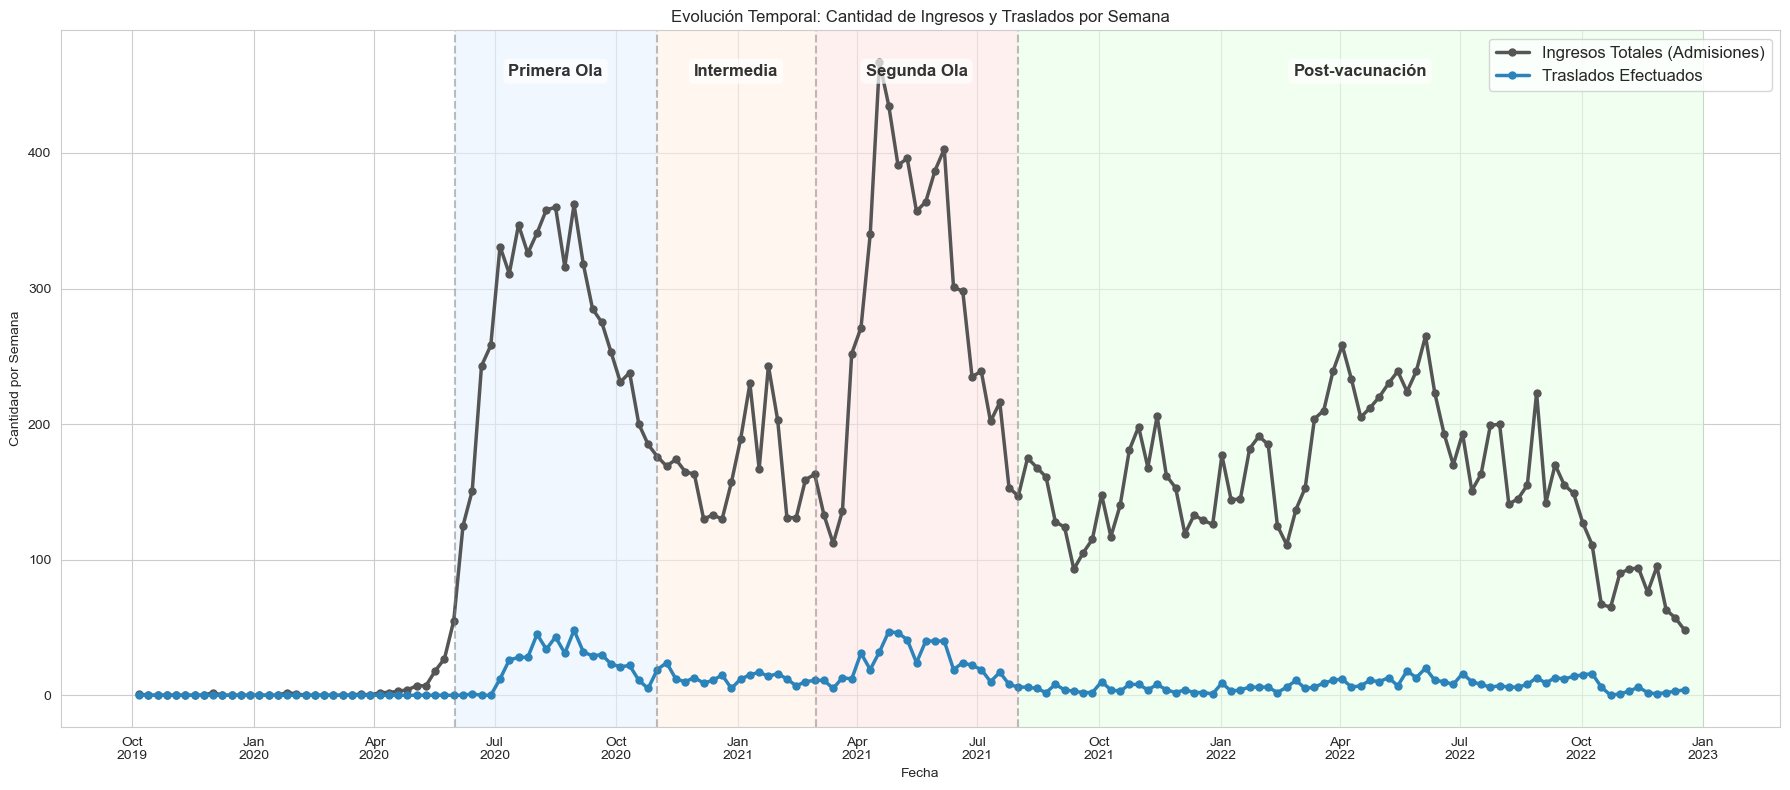

In [24]:
# 9. ANÁLISIS ESTADÍSTICO Y TEMPORAL (DRY)
# ==========================================
mask_validos_stats = (df_traslados['hospital_ingreso'].isin(hospitales_conocidos)) & (df_traslados['hospital_destino'].isin(hospitales_conocidos)) & (df_traslados['hospital_ingreso'] != df_traslados['hospital_destino'])
df_traslados_stats = df_traslados[mask_validos_stats].copy()

# Funciones de Anotación Originales (Intactas para mantener tus márgenes Log)
def agregar_valores_scatter(ax, x_vals, y_vals):
    for x, y in zip(x_vals, y_vals):
        if y > 0: ax.text(x, y * 1.25, f'{int(y)}', ha="center", va="bottom", fontsize=10, fontweight='bold', color='#2b2b2b')
    ax.set_ylim(0.5, (max(y_vals) if len(y_vals) > 0 else 1) * 5)

def agregar_valores_barras(ax):
    for p in ax.patches:
        h = p.get_height()
        if h > 0: ax.text(p.get_x() + p.get_width() / 2., (p.get_y() + h) * 1.2, f'{int(h)}', ha="center", va="bottom", fontsize=10, fontweight='bold', color='#2b2b2b')
    ax.set_ylim(0.5, ax.get_ylim()[1] * 5)

def agregar_valores_totales(ax):
    max_y_per_x = {}
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            x_c, y_t = p.get_x() + p.get_width() / 2., p.get_y() + h
            if x_c not in max_y_per_x or y_t > max_y_per_x[x_c]: max_y_per_x[x_c] = y_t
    
    max_y_axis = ax.get_ylim()[1]
    for x_c, total_height in max_y_per_x.items():
        if total_height >= (max_y_axis * 0.02):
            ax.text(x_c, total_height + (max_y_axis * 0.01), f'{int(total_height)}', ha="center", va="bottom", fontsize=9, fontweight='bold', color='#333333')
    ax.set_ylim(0, max_y_axis * 1.1)

# --- 9.1 Lollipop Chart ---
def graficar_lollipop(df_stats, df_pacientes, es_global=False):
    if es_global:
        fig, axes = plt.subplots(figsize=(14, 8)); axes = [axes]
        iteracion = [("Global", None, None)]
    else:
        fig, axes = plt.subplots(2, 2, figsize=(18, 12))
        fig.suptitle("Número de traslados por paciente por Periodo (Escala Log)", fontsize=22, fontweight='bold', y=0.98)
        axes = axes.flatten()
        iteracion = PERIODOS

    fig.patch.set_facecolor('white')

    for ax, (titulo, inicio, fin) in zip(axes, iteracion):
        mask_p = df_pacientes['fecha_ingreso'].between(inicio, fin) if inicio else pd.Series(True, index=df_pacientes.index)
        mask_t = df_stats['fecha_egreso'].between(inicio, fin) if inicio else pd.Series(True, index=df_stats.index)
        
        df_t_per, df_p_per = df_stats[mask_t], df_pacientes[mask_p]
        cero_traslados = len(set(df_p_per['paciente_id']) - set(df_t_per['paciente_id']))
        
        if not df_t_per.empty:
            conteo = df_t_per.groupby('paciente_id').size().value_counts().sort_index()
            ax.vlines(x=conteo.index, ymin=0.5, ymax=conteo.values, color='#4c72b0', alpha=0.4, linewidth=3 if not es_global else 4, zorder=2)
            sns.scatterplot(x=conteo.index, y=conteo.values, color='#4c72b0', s=150 if not es_global else 250, edgecolor='black', linewidth=1.5, ax=ax, zorder=3)
            ax.set_yscale('log'); agregar_valores_scatter(ax, conteo.index, conteo.values)
        
        ax.set(title=titulo, xlabel="Cantidad de traslados", ylabel="Cantidad de pacientes (Log)")
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.legend(handles=[mlines.Line2D([], [], color='none', marker='None', label=f'0 traslados: {cero_traslados}')], loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, fontsize=12, handlelength=0, handletextpad=0)

    plt.tight_layout(rect=[0, 0, 0.88 if not es_global else 0.85, 0.96 if not es_global else 1], pad=3.0)
    plt.show()

graficar_lollipop(df_traslados_stats, pacientes, es_global=False)
graficar_lollipop(df_traslados_stats, pacientes, es_global=True)

# --- 9.2 Tiempo en el Sistema Histograms ---
tiempo_trayectorias_todas = pacientes.groupby('paciente_id').agg(ingreso=('fecha_ingreso', 'min'), egreso=('fecha_egreso', 'max'))
tiempo_trayectorias_todas['dias_en_sistema'] = (tiempo_trayectorias_todas['egreso'] - tiempo_trayectorias_todas['ingreso']).dt.days
tiempo_trayectorias_todas = tiempo_trayectorias_todas[tiempo_trayectorias_todas['dias_en_sistema'] >= 0].copy()

df_trasladados = tiempo_trayectorias_todas[tiempo_trayectorias_todas.index.isin(set(df_traslados_stats['paciente_id']))]
limite_p99 = tiempo_trayectorias_todas['dias_en_sistema'].quantile(0.99)
max_plot = int(limite_p99) if not pd.isna(limite_p99) else int(tiempo_trayectorias_todas['dias_en_sistema'].max())
bins_5dias = np.arange(0, max_plot + 5, 5)

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 7))
fig2.patch.set_facecolor('white')
fig2.suptitle("Tiempo total en el sistema: Global vs Trasladados (Escala Log)", fontsize=22, fontweight='bold', y=1.02)

for ax, titulo, df_subset, color in zip(axes2, ["Global", "Solo Trasladados"], [tiempo_trayectorias_todas, df_trasladados], ['#4c72b0', '#1a9850']):
    sns.histplot(df_subset['dias_en_sistema'], bins=bins_5dias, color=color, ax=ax, edgecolor='black', alpha=0.8)
    ax.set_yscale('log'); agregar_valores_barras(ax)
    ax.set(title=titulo, xlabel="Días totales", ylabel="Cantidad de personas (Log)", xlim=(0, max_plot), xticks=np.arange(0, max_plot + 5, 10))
    mediana = df_subset['dias_en_sistema'].median()
    if not pd.isna(mediana):
        ax.axvline(mediana, color='red', linestyle='dashed', linewidth=2)
        ax.text(mediana + 1, ax.get_ylim()[1]*0.5, f'Mediana: {int(mediana)} días', color='red', fontweight='bold')
plt.tight_layout()
plt.show()

# --- 9.3 Scatter de Traslados vs Tiempo (< 4) ---
df_cruce = pd.merge(tiempo_trayectorias_todas, df_traslados_stats.groupby('paciente_id').size().reset_index(name='cantidad_traslados'), on='paciente_id', how='inner')
df_plot = df_cruce[df_cruce['cantidad_traslados'] < 4].copy()
df_plot['dias_plot'] = df_plot['dias_en_sistema'].replace(0, 0.5)

fig3, ax3 = plt.subplots(figsize=(12, 8))
fig3.patch.set_facecolor('white')
sns.stripplot(data=df_plot, x='cantidad_traslados', y='dias_plot', color='#4c72b0', alpha=0.4, jitter=0.2, size=5, ax=ax3, zorder=1)
sns.pointplot(data=df_plot, x='cantidad_traslados', y='dias_plot', estimator=np.mean, errorbar='sd', color='#d62728', markers='D', capsize=0.1, err_kws={'linewidth': 2}, ax=ax3, zorder=3)

ax3.set_yscale('log')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:g}'.format(y)))
ax3.set(title="Relación entre Cantidad de Traslados y Días en el Sistema\n(Solo pacientes con 1 a 3 traslados)", xlabel="Cantidad de Traslados", ylabel="Días totales en el sistema (Escala Log)")
ax3.legend(handles=[mlines.Line2D([], [], color='#d62728', marker='D', markersize=8, label='Promedio ± Desvío Estándar')], loc='upper left', frameon=True, fontsize=12)
plt.tight_layout()
plt.show()

# --- 9.4 Tiempo hasta Traslado (Barras Apiladas) ---
df_movimientos = df_traslados_stats.copy()
df_movimientos['dias_antes_traslado'] = (df_movimientos['fecha_egreso'] - df_movimientos['fecha_ingreso']).dt.days
df_movimientos = df_movimientos[df_movimientos['dias_antes_traslado'] >= 0]
df_movimientos['tipo_hospital'] = df_movimientos['hospital_ingreso'].apply(clasificar_hospital) # Usamos la func auxiliar DRY

limite_p99_nodo = df_movimientos['dias_antes_traslado'].quantile(0.99) if not df_movimientos.empty else 30
max_plot_nodo = int(limite_p99_nodo) if not pd.isna(limite_p99_nodo) else 30
bins_mov_5 = np.arange(0, max_plot_nodo + 5, 5)

def graficar_tiempo_traslado(df_mov, es_global=False):
    if es_global:
        fig, axes = plt.subplots(figsize=(14, 8)); axes = [axes]
        iteracion = [("Tiempo hasta traslado (Estadía en nodo origen) - Global", None, None)]
    else:
        fig, axes = plt.subplots(2, 2, figsize=(18, 12))
        fig.suptitle("Tiempo hasta traslado (Estadía en nodo origen) por Periodo", fontsize=22, fontweight='bold', y=0.98)
        axes = axes.flatten()
        iteracion = PERIODOS

    fig.patch.set_facecolor('white')

    for ax, (titulo, inicio, fin) in zip(axes, iteracion):
        mask_m = df_mov['fecha_egreso'].between(inicio, fin) if inicio else pd.Series(True, index=df_mov.index)
        df_m_per = df_mov[mask_m]
        
        if not df_m_per.empty:
            sns.histplot(data=df_m_per, x='dias_antes_traslado', hue='tipo_hospital', palette=COLORES_ORIGEN, multiple='stack', bins=bins_mov_5, ax=ax, edgecolor='white')
            agregar_valores_totales(ax)
            
        ax.set(title=titulo, xlabel="Días de estadía antes de ser trasladado", ylabel="Cantidad de traslados", xlim=(0, max_plot_nodo))

    plt.tight_layout(rect=[0, 0, 1, 0.95], pad=3.0)
    plt.show()

graficar_tiempo_traslado(df_movimientos, es_global=False)
graficar_tiempo_traslado(df_movimientos, es_global=True)

# --- 9.5 Evolución Temporal ---
fig4, ax4 = plt.subplots(figsize=(18, 8))
fig4.patch.set_facecolor('white')

df_ts = pd.concat([
    pacientes.set_index('fecha_ingreso').resample('W').size().rename('Ingresos Totales'),
    df_traslados_stats.set_index('fecha_egreso').resample('W').size().rename('Traslados')
], axis=1).fillna(0)

ax4.plot(df_ts.index, df_ts['Ingresos Totales'], label='Ingresos Totales (Admisiones)', color='#555555', linewidth=2.5, marker='o', markersize=5)
ax4.plot(df_ts.index, df_ts['Traslados'], label='Traslados Efectuados', color='#2b83ba', linewidth=2.5, marker='o', markersize=5)

colores_fondo = ['#e6f2ff', '#fff0e6', '#ffe6e6', '#e6ffe6'] 
for i, (titulo, inicio, fin) in enumerate(PERIODOS):
    f_ini, f_fin = pd.to_datetime(inicio), pd.to_datetime(fin)
    ax4.axvspan(f_ini, f_fin, color=colores_fondo[i % len(colores_fondo)], alpha=0.6)
    ax4.axvline(f_ini, color='gray', linestyle='--', alpha=0.5)
    ax4.text(f_ini + (f_fin - f_ini)/2, ax4.get_ylim()[1]*0.95, titulo, ha='center', va='top', fontsize=12, fontweight='bold', color='#333333', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

ax4.set(title="Evolución Temporal: Cantidad de Ingresos y Traslados por Semana", xlabel="Fecha", ylabel="Cantidad por Semana")
ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax4.legend(loc='upper right', fontsize=12, frameon=True)
plt.tight_layout()
plt.show()